In [1]:

import intake
import cartopy.feature as cf
import cmocean
import healpy as hp
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from matplotlib.colors import Normalize
from matplotlib.patches import Rectangle
import scipy.signal as signal
import math
import time
import os
import pickle
from scipy import fft
import cmaps  
from typing import Optional
import sys
import matplotlib.colors as mcolors
from pathlib import Path
WAVE_TOOLS_PATH = Path("/work/mh1498/m301257/wave_tools")
sys.path.insert(0, str(WAVE_TOOLS_PATH.parent))
from wave_tools.utils import dataarray_healpix_to_equatorial_latlon,get_region_healpix_,create_cmap_from_string
from  wave_tools.plotting import get_cckw_envelope_curve,setup_map_axes,set_axis_for_wave    
# 重新导入修复后的模块
import wave_tools.spectral
from wave_tools.spectral import WKSpectralAnalysis, SpectralConfig
from wave_tools.plotting import set_axis_for_wave
from wave_tools import matsuno as mp
print("="*70)
print("✅ 模块重新加载完成")
print("="*70)

✅ 模块重新加载完成


### 6.1 设置数据保存路径和加载函数

In [2]:

# 创建数据保存目录
DATA_DIR = "/work/mh1498/m301257/processed_data"
os.makedirs(DATA_DIR, exist_ok=True)

# 定义保存路径
CNTL_INTERP_PATH = os.path.join(DATA_DIR, "pr_cntl_2deg_interp.nc")
P4K_INTERP_PATH = os.path.join(DATA_DIR, "pr_4k_2deg_interp.nc")
CO2_INTERP_PATH = os.path.join(DATA_DIR, "pr_4co2_2deg_interp.nc")

# 频谱分析结果保存路径
CNTL_SPECTRUM_PATH = os.path.join(DATA_DIR, "spectrum_cntl.pkl")
P4K_SPECTRUM_PATH = os.path.join(DATA_DIR, "spectrum_4k.pkl")
CO2_SPECTRUM_PATH = os.path.join(DATA_DIR, "spectrum_4co2.pkl")

fig_save_path = os.path.join("/home/m/m301257/", "fig",'fig01_spectral_analysis') 
os.makedirs(fig_save_path, exist_ok=True)

print("="*70)
print("📁 数据保存路径设置完成")
print("="*70)
print(f"插值数据目录: {DATA_DIR}")
print(f"  CNTL:  {CNTL_INTERP_PATH}")
print(f"  4K:    {P4K_INTERP_PATH}")
print(f"  4CO2:  {CO2_INTERP_PATH}")
print(f"\n频谱结果目录:")
print(f"  CNTL:  {CNTL_SPECTRUM_PATH}")
print(f"  4K:    {P4K_SPECTRUM_PATH}")
print(f"  4CO2:  {CO2_SPECTRUM_PATH}")
print("="*70)

📁 数据保存路径设置完成
插值数据目录: /work/mh1498/m301257/processed_data
  CNTL:  /work/mh1498/m301257/processed_data/pr_cntl_2deg_interp.nc
  4K:    /work/mh1498/m301257/processed_data/pr_4k_2deg_interp.nc
  4CO2:  /work/mh1498/m301257/processed_data/pr_4co2_2deg_interp.nc

频谱结果目录:
  CNTL:  /work/mh1498/m301257/processed_data/spectrum_cntl.pkl
  4K:    /work/mh1498/m301257/processed_data/spectrum_4k.pkl
  4CO2:  /work/mh1498/m301257/processed_data/spectrum_4co2.pkl


In [3]:
# 🔄 从保存的文件加载频谱分析结果
print("="*70)
print("📂 从保存的文件加载频谱分析结果")
print("="*70)

import pickle

def load_spectrum_analysis(save_path, experiment_name):
    """从pickle文件加载频谱分析结果"""
    if not os.path.exists(save_path):
        raise FileNotFoundError(f"未找到保存的频谱文件: {save_path}")
    
    print(f"  加载 {experiment_name} 频谱数据...")
    with open(save_path, 'rb') as f:
        result = pickle.load(f)
    print(f"  ✅ {experiment_name} 加载完成")
    
    # 检查是否是字典格式
    if isinstance(result, dict):
        return result['analysis'], result['norm_sym'], result['norm_asym']
    else:
        # 如果是旧格式（元组），直接返回
        return result

try:
    # 加载三个实验的频谱分析结果
    cntl_result = load_spectrum_analysis(CNTL_SPECTRUM_PATH, "CNTL")
    p4k_result = load_spectrum_analysis(P4K_SPECTRUM_PATH, "4K")
    co2_result = load_spectrum_analysis(CO2_SPECTRUM_PATH, "4CO2")
    
    # 解包结果
    analysis_cntl, norm_sym_cntl, norm_asym_cntl = cntl_result
    analysis_4k, norm_sym_4k, norm_asym_4k = p4k_result
    analysis_4co2, norm_sym_4co2, norm_asym_4co2 = co2_result
    
    # 为了向后兼容，创建 mmday 版本的别名（因为数据已经是 mm/day 单位）
    analysis_cntl_mmday = analysis_cntl
    analysis_4k_mmday = analysis_4k
    analysis_4co2_mmday = analysis_4co2

except FileNotFoundError as e:
    print(f"\n❌ 错误: {e}")
    print("\n⚠️  需要先运行频谱计算代码来生成这些文件！")
    print("   请运行 Section 6.3 中的 compute_or_load_spectrum 函数")
except Exception as e:
    print(f"\n❌ 加载频谱数据时出错: {e}")
    import traceback
    traceback.print_exc()

📂 从保存的文件加载频谱分析结果
  加载 CNTL 频谱数据...
  ✅ CNTL 加载完成
  加载 4K 频谱数据...
  ✅ 4K 加载完成
  加载 4CO2 频谱数据...
  ✅ 4CO2 加载完成


In [4]:
# 验证加载的数据
print("="*70)
print("🔍 验证加载的频谱数据")
print("="*70)

# 检查对象类型
print(f"\n数据类型:")
print(f"  analysis_cntl: {type(analysis_cntl)}")
print(f"  analysis_4k: {type(analysis_4k)}")
print(f"  analysis_4co2: {type(analysis_4co2)}")

# 检查power_symmetric是否存在
print(f"\n检查关键属性:")
for name, analysis in [("CNTL", analysis_cntl), ("4K", analysis_4k), ("4CO2", analysis_4co2)]:
    try:
        sym_shape = analysis.power_symmetric.shape
        asym_shape = analysis.power_antisymmetric.shape
        print(f"  {name:5s} - power_symmetric: {sym_shape}, power_antisymmetric: {asym_shape}")
    except AttributeError as e:
        print(f"  {name:5s} - ❌ 缺少属性: {e}")

# 检查数值范围
print(f"\n数值范围检查:")
for name, analysis in [("CNTL", analysis_cntl), ("4K", analysis_4k), ("4CO2", analysis_4co2)]:
    try:
        sym_min = np.nanmin(analysis.power_symmetric.values)
        sym_max = np.nanmax(analysis.power_symmetric.values)
        asym_min = np.nanmin(analysis.power_antisymmetric.values)
        asym_max = np.nanmax(analysis.power_antisymmetric.values)
        print(f"  {name:5s} sym:  {sym_min:.2e} - {sym_max:.2e}")
        print(f"  {name:5s} asym: {asym_min:.2e} - {asym_max:.2e}")
    except Exception as e:
        print(f"  {name:5s} - ❌ 错误: {e}")

print("\n" + "="*70)
print("✅ 数据验证完成")

🔍 验证加载的频谱数据

数据类型:
  analysis_cntl: <class 'wave_tools.spectral.WKSpectralAnalysis'>
  analysis_4k: <class 'wave_tools.spectral.WKSpectralAnalysis'>
  analysis_4co2: <class 'wave_tools.spectral.WKSpectralAnalysis'>

检查关键属性:
  CNTL  - power_symmetric: (48, 179), power_antisymmetric: (48, 179)
  4K    - power_symmetric: (48, 179), power_antisymmetric: (48, 179)
  4CO2  - power_symmetric: (48, 179), power_antisymmetric: (48, 179)

数值范围检查:
  CNTL  sym:  2.43e-12 - 5.38e-11
  CNTL  asym: 2.51e-12 - 6.09e-11
  4K    sym:  3.61e-12 - 9.28e-11
  4K    asym: 3.43e-12 - 8.67e-11
  4CO2  sym:  2.34e-12 - 5.02e-11
  4CO2  asym: 2.34e-12 - 5.54e-11

✅ 数据验证完成


In [5]:
# 🎯 一键检查：验证频谱分析是否完成
print("="*70)
print("📊 频谱分析完成检查")
print("="*70)

try:
    # 检查所有必需的变量
    vars_to_check = {
        'CNTL': ('analysis_cntl', 'norm_sym_cntl', 'norm_asym_cntl'),
        '4K': ('analysis_4k', 'norm_sym_4k', 'norm_asym_4k'),
        '4CO2': ('analysis_4co2', 'norm_sym_4co2', 'norm_asym_4co2')
    }
    
    all_present = True
    for exp_name, vars in vars_to_check.items():
        print(f"\n{exp_name} 实验:")
        for var in vars:
            if var in globals():
                print(f"  ✅ {var}")
            else:
                print(f"  ❌ {var} (未定义)")
                all_present = False
    
    if all_present:
        print("\n" + "="*70)
        print("✅ 所有频谱分析已完成！可以运行绘图代码了。")
        print("="*70)
        
        # 显示统计信息
        print("\n📈 快速统计:")
        print(f"  CNTL  归一化功率范围: {np.nanmin(norm_sym_cntl.values):.3f} - {np.nanmax(norm_sym_cntl.values):.3f}")
        print(f"  4K    归一化功率范围: {np.nanmin(norm_sym_4k.values):.3f} - {np.nanmax(norm_sym_4k.values):.3f}")
        print(f"  4CO2  归一化功率范围: {np.nanmin(norm_sym_4co2.values):.3f} - {np.nanmax(norm_sym_4co2.values):.3f}")
    else:
        print("\n" + "="*70)
        print("⚠️  频谱分析未完成，请运行上面的分析代码！")
        print("="*70)
        
except Exception as e:
    print(f"\n❌ 检查失败: {e}")
    print("⚠️  请先运行 Section 6.3 的所有代码单元格！")

📊 频谱分析完成检查

CNTL 实验:
  ✅ analysis_cntl
  ✅ norm_sym_cntl
  ✅ norm_asym_cntl

4K 实验:
  ✅ analysis_4k
  ✅ norm_sym_4k
  ✅ norm_asym_4k

4CO2 实验:
  ✅ analysis_4co2
  ✅ norm_sym_4co2
  ✅ norm_asym_4co2

✅ 所有频谱分析已完成！可以运行绘图代码了。

📈 快速统计:
  CNTL  归一化功率范围: 0.757 - 1.573
  4K    归一化功率范围: 0.784 - 1.963
  4CO2  归一化功率范围: 0.752 - 1.627


### 6.4 图1: 三个模型的频谱图对比

📊 图1: 三个模型的频谱图对比（对称+反对称分量）


/home/m/m301257/.conda/envs/xianpu/lib/python3.12/site-packages/matplotlib/text.py:763: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  posy = float(self.convert_yunits(y))
/home/m/m301257/.conda/envs/xianpu/lib/python3.12/site-packages/matplotlib/text.py:568: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  posy = float(self.convert_yunits(self._y))
/home/m/m301257/.conda/envs/xianpu/lib/python3.12/site-packages/matplotlib/text.py:906: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  y = float(self.convert_yunits(self._y))


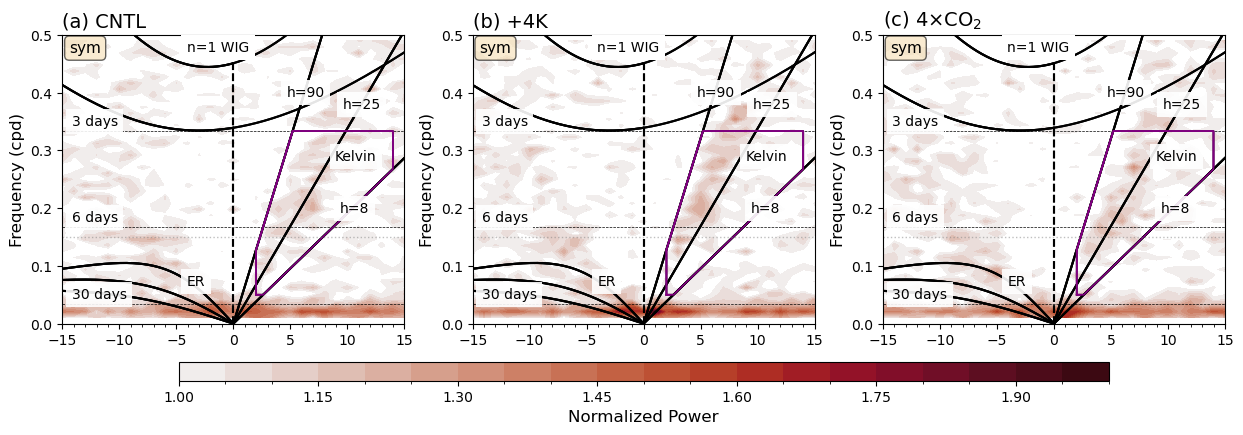

In [6]:
print("="*70)
print("📊 图1: 三个模型的频谱图对比（对称+反对称分量）")
print("="*70)

# 创建3x2子图 - 左列：反对称(MRG)，右列：对称(Kelvin)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
# 设置色图和等高线
cmap = cmaps.cmocean_amp
levels = np.linspace(1, 2, 21)
# 准备数据：反对称和对称
experiments = [
    ("CNTL",  norm_sym_cntl, 0),
    ("+4K", norm_sym_4k, 1),
    (r"4$\times$CO$_{2}$", norm_sym_4co2, 2)
]

for exp_name, data_sym, row in experiments:

    # 右列：对称 (Kelvin)
    im_sym = data_sym.plot.contourf(
        ax=axes[row], 
        cmap=cmap, 
        add_colorbar=False,
        extend='neither', 
        levels=levels
    )
    axes[row].set_title(f"({chr(97+row)}) {exp_name}", 
                          fontsize=14,  loc='left')

# 格式化所有子图
for i, ax in enumerate(axes.flat):

    set_axis_for_wave(ax, text_size=16, kelvin_box=True)
    ax.axvline(0, linestyle='--', color='black', linewidth=1.5, alpha=0.7)
    ax.axhline(0.15, linestyle=':', color='gray', linewidth=1, alpha=0.5)
    ax.set_xlim([-15, 15])
    ax.set_ylim([0, 0.5])
    
    # 只在最底部一行显示x轴标签
    row_idx = i // 2
    if row_idx == 2:
        ax.set_xlabel("Wavenumber", fontsize=12)
    else:
        ax.set_xlabel("")
    ax.set_ylabel("Frequency (cpd)", fontsize=12)
    
    # 添加对称性标签
    col_idx = i % 2
    label_text =  'sym'
    ax.text(0.02, 0.98, label_text, 
            transform=ax.transAxes,
            fontsize=11, va='top', ha='left',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

# 添加共享colorbar
cbar = fig.colorbar(im_sym, ax=axes, orientation='horizontal',
                    shrink=0.8, aspect=50, pad=0.1)
cbar.set_label('Normalized Power', fontsize=12)

# plt.show()
# fig.savefig(f"{fig_save_path}/fig01_spectrum_comparison_cntl_4k_4co2_for_kelvin.png", dpi=300, bbox_inches='tight')


### 6.5 图2: 4K和4CO2实验与CNTL的差异（对称分量）

📊 图2: 4K和4CO2与CNTL的差异（对称+反对称分量）


/home/m/m301257/.conda/envs/xianpu/lib/python3.12/site-packages/matplotlib/text.py:763: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  posy = float(self.convert_yunits(y))
/home/m/m301257/.conda/envs/xianpu/lib/python3.12/site-packages/matplotlib/text.py:568: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  posy = float(self.convert_yunits(self._y))
/home/m/m301257/.conda/envs/xianpu/lib/python3.12/site-packages/matplotlib/text.py:906: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  y = float(self.convert_yunits(self._y))


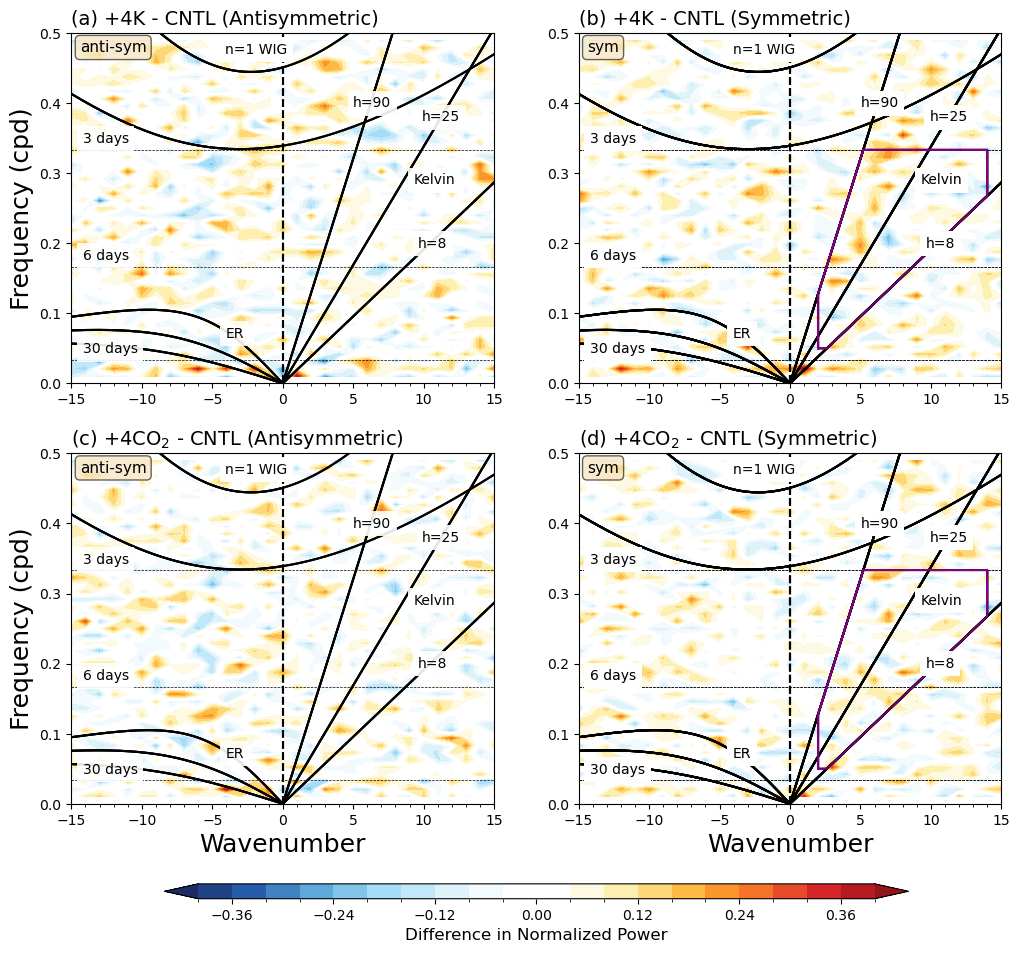

In [7]:
print("="*70)
print("📊 图2: 4K和4CO2与CNTL的差异（对称+反对称分量）")
print("="*70)

# 计算差异 - 对称和反对称
diff_4k_sym = norm_sym_4k - norm_sym_cntl
diff_4co2_sym = norm_sym_4co2 - norm_sym_cntl
diff_4k_asym = norm_asym_4k - norm_asym_cntl
diff_4co2_asym = norm_asym_4co2 - norm_asym_cntl

# 创建2x2子图
fig, axes = plt.subplots(2, 2, figsize=(12, 13))
set_axis_for_wave(axes[0,1], text_size=16)
set_axis_for_wave(axes[1,1], text_size=16)
# 设置差异色图（发散型色标）
levels_diff = np.linspace(-0.4, 0.4, 21)
cmap_diff = cmaps.BlueWhiteOrangeRed

# === 第1行：4K - CNTL ===
# 左：反对称
im1 = diff_4k_asym.plot.contourf(
    ax=axes[0, 0], 
    cmap=cmap_diff,
    add_colorbar=False,
    extend='both', 
    levels=levels_diff
)
axes[0, 0].set_title("(a) +4K - CNTL (Antisymmetric)", fontsize=14, loc='left')

# 右：对称
im2 = diff_4k_sym.plot.contourf(
    ax=axes[0, 1], 
    cmap=cmap_diff,
    add_colorbar=False,
    extend='both', 
    levels=levels_diff
)
axes[0, 1].set_title("(b) +4K - CNTL (Symmetric)", fontsize=14,  loc='left')

# === 第2行：4CO2 - CNTL ===
# 左：反对称
im3 = diff_4co2_asym.plot.contourf(
    ax=axes[1, 0], 
    cmap=cmap_diff,
    add_colorbar=False,
    extend='both', 
    levels=levels_diff
)
axes[1, 0].set_title("(c) +4CO$_{2}$ - CNTL (Antisymmetric)", fontsize=14,  loc='left')

# 右：对称
im4 = diff_4co2_sym.plot.contourf(
    ax=axes[1, 1], 
    cmap=cmap_diff,
    add_colorbar=False,
    extend='both', 
    levels=levels_diff
)
axes[1, 1].set_title("(d) +4CO$_{2}$ - CNTL (Symmetric)", fontsize=14, loc='left')

# 格式化所有子图
for i, ax in enumerate(axes.flat):
    if i % 2 == 0:
        
        set_axis_for_wave(ax, text_size=16, kelvin_box=False)
    else:
        set_axis_for_wave(ax, text_size=16, kelvin_box=True)
    ax.axvline(0, linestyle='--', color='black', linewidth=1.5, alpha=0.7)
    
    ax.set_xlim([-15, 15])
    ax.set_ylim([0, 0.5])
    
    # 只在底部一行显示x轴标签
    row_idx = i // 2
    if row_idx == 1:
        ax.set_xlabel("Wavenumber", fontsize=18)
    else:
        ax.set_xlabel("")
    
    if i % 2 == 0:
        ax.set_ylabel("Frequency (cpd)", fontsize=18)
    else:
        ax.set_ylabel("")
    
    # 添加对称性标签
    col_idx = i % 2
    label_text = 'anti-sym' if col_idx == 0 else 'sym'
    ax.text(0.02, 0.98, label_text, 
            transform=ax.transAxes,
            fontsize=11, va='top', ha='left',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

# 添加共享colorbar
cbar = fig.colorbar(im1, ax=axes, orientation='horizontal',
                    shrink=0.8, aspect=50, pad=0.08)
cbar.set_label('Difference in Normalized Power', fontsize=12)

plt.show()
fig.savefig(f"{fig_save_path}/fig02_spectrum_difference_4k_4co2_vs_cntl_for_kelvin.png", dpi=300, bbox_inches='tight')
plt.close(fig)  # 释放内存，避免崩溃

### 6.6 图3: 功率谱的比较（原始功率谱）

📊 图3: 功率谱的比较（原始功率谱，mm/day单位，对称+反对称）
✅ 使用 mm/day 单位的频谱数据

检查功率谱数据范围...
  CNTL  对称功率: 2.43e-12 - 5.38e-11
  CNTL  反对称功率: 2.51e-12 - 6.09e-11
  +4K   对称功率: 3.61e-12 - 9.28e-11
  +4K   反对称功率: 3.43e-12 - 8.67e-11
  +4CO$_{2}$ 对称功率: 2.34e-12 - 5.02e-11
  +4CO$_{2}$ 反对称功率: 2.34e-12 - 5.54e-11

✅ 使用自动计算的色标范围:
  实际数据: 2.34e-12 - 9.28e-11
  对数值: -11.63 - -10.03
  原始值: 2.34e-12 - 9.28e-11
  跨度: 1.60 个数量级


/home/m/m301257/.conda/envs/xianpu/lib/python3.12/site-packages/matplotlib/text.py:763: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  posy = float(self.convert_yunits(y))
/home/m/m301257/.conda/envs/xianpu/lib/python3.12/site-packages/matplotlib/text.py:568: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  posy = float(self.convert_yunits(self._y))
/home/m/m301257/.conda/envs/xianpu/lib/python3.12/site-packages/matplotlib/text.py:906: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  y = float(self.convert_yunits(self._y))


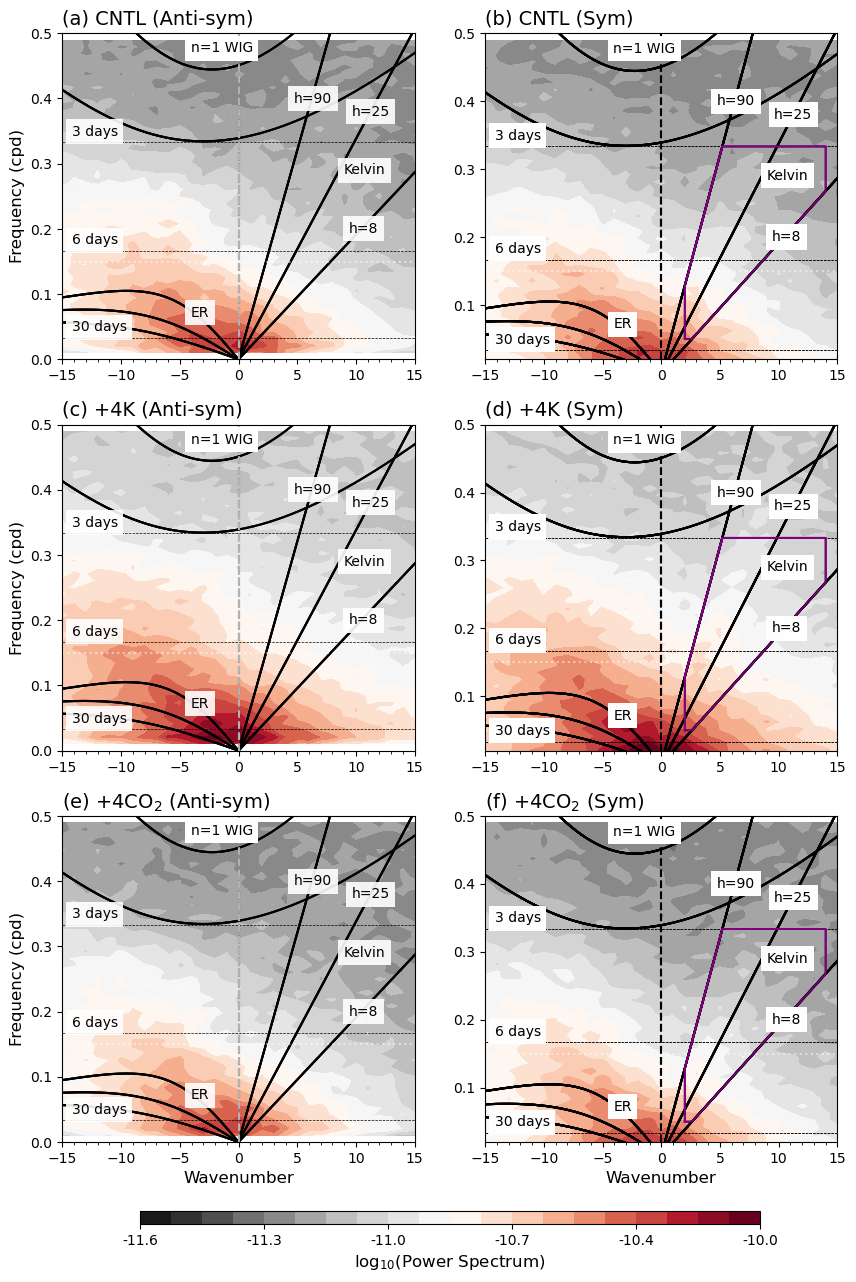

In [8]:
print("="*70)
print("📊 图3: 功率谱的比较（原始功率谱，mm/day单位，对称+反对称）")
print("="*70)

# ========== 可手动调整的参数 ==========
# 设置对数刻度的范围（log10值）
MANUAL_LOG_VMIN = -12.  # 手动设置最小值的对数
MANUAL_LOG_VMAX = -10.  # 手动设置最大值的对数
USE_MANUAL_RANGE = False  # True: 使用手动设置; False: 使用数据自动计算
# ======================================

# 使用转换后的数据（mm/day单位）
try:
    # 检查是否已经计算了mm/day单位的频谱
    test_var = analysis_cntl_mmday
    print("✅ 使用 mm/day 单位的频谱数据")
    analysis_list = [analysis_cntl_mmday, analysis_4k_mmday, analysis_4co2_mmday]
    exp_names = ["CNTL", "+4K", "+4CO$_{2}$"]
except NameError:
    print("⚠️  警告：未找到 mm/day 单位的数据，使用原始数据")
    print("   建议先运行上面的单位转换代码单元！")
    analysis_list = [analysis_cntl, analysis_4k, analysis_4co2]
    exp_names = ["CNTL", "+4K", "+4CO$_{2}$"]

# 首先检查功率谱的实际数值范围
print("\n检查功率谱数据范围...")
for name, analysis in zip(exp_names, analysis_list):
    vmin_data_sym = np.nanmin(analysis.power_symmetric.values)
    vmax_data_sym = np.nanmax(analysis.power_symmetric.values)
    vmin_data_asym = np.nanmin(analysis.power_antisymmetric.values)
    vmax_data_asym = np.nanmax(analysis.power_antisymmetric.values)
    print(f"  {name:5s} 对称功率: {vmin_data_sym:.2e} - {vmax_data_sym:.2e}")
    print(f"  {name:5s} 反对称功率: {vmin_data_asym:.2e} - {vmax_data_asym:.2e}")

# 创建3x2子图：左列反对称，右列对称
fig, axes = plt.subplots(3, 2, figsize=(10, 18))

# 计算实际的数据范围
all_data = []
for a in analysis_list:
    all_data.extend([a.power_symmetric.values, a.power_antisymmetric.values])

if USE_MANUAL_RANGE:
    # 使用手动设置的范围
    log_vmin = MANUAL_LOG_VMIN
    log_vmax = MANUAL_LOG_VMAX
    vmin = 10**log_vmin
    vmax = 10**log_vmax
    print(f"\n✅ 使用手动设置的色标范围:")
    print(f"  对数值: {log_vmin:.2f} - {log_vmax:.2f}")
    print(f"  原始值: {vmin:.2e} - {vmax:.2e}")
else:
    # 自动计算范围
    vmin_actual = np.nanmin([np.nanmin(d) for d in all_data])
    vmax_actual = np.nanmax([np.nanmax(d) for d in all_data])
    
    vmin = max(vmin_actual, 1e-20)
    vmax = vmax_actual
    
    log_vmin = np.log10(vmin)
    log_vmax = np.log10(vmax)
    
    print(f"\n✅ 使用自动计算的色标范围:")
    print(f"  实际数据: {vmin_actual:.2e} - {vmax_actual:.2e}")
    print(f"  对数值: {log_vmin:.2f} - {log_vmax:.2f}")
    print(f"  原始值: {vmin:.2e} - {vmax:.2e}")

print(f"  跨度: {log_vmax - log_vmin:.2f} 个数量级")

# 创建对数间隔的等高线级别
levels_power = np.logspace(log_vmin, log_vmax, 21)

# 绘制三个实验的原始功率谱：反对称 + 对称
for row, (analysis, exp_name) in enumerate(zip(analysis_list, exp_names)):
    # 左列：反对称
    im_asym = analysis.power_antisymmetric.plot.contourf(
        ax=axes[row, 0], 
        cmap=cmaps.MPL_RdGy_r,
        add_colorbar=False,
        extend='neither',
        levels=levels_power,
        norm=mcolors.LogNorm(vmin=vmin, vmax=vmax)
    )
    set_axis_for_wave(axes[row, 0], text_size=16, kelvin_box=False)
    axes[row, 0].set_title(f"({chr(97+row*2)}) {exp_name} (Anti-sym)", loc='left', fontsize=14)
    
    # 右列：对称
    im_sym = analysis.power_symmetric.plot.contourf(
        ax=axes[row, 1], 
        cmap=cmaps.MPL_RdGy_r,
        add_colorbar=False,
        extend='neither',
        levels=levels_power,
        norm=mcolors.LogNorm(vmin=vmin, vmax=vmax)
    )
    set_axis_for_wave(axes[row, 1], text_size=16, kelvin_box=False)
    axes[row, 1].set_title(f"({chr(98+row*2)}) {exp_name} (Sym)", loc='left', fontsize=14)

# 格式化所有子图
for i, ax in enumerate(axes.flat):
    ax.axvline(0, linestyle='--', color='white', alpha=0.7)
    ax.axhline(0.15, linestyle=':', color='white', alpha=0.5)
    ax.set_xlim([-15, 15])
    ax.set_ylim([0, 0.5])
    
    row_idx = i // 2
    if row_idx == 2:
        ax.set_xlabel("Wavenumber", fontsize=12)
    else:
        ax.set_xlabel("")
        
        
    if i % 2 == 0:
        ax.set_ylabel("Frequency (cpd)", fontsize=12)
    else:   
        ax.set_ylabel("", fontsize=12)
        set_axis_for_wave(ax, text_size=16, kelvin_box=True)

# 添加共享colorbar
cbar = fig.colorbar(im_sym, ax=axes, orientation='horizontal',
                    shrink=0.8, aspect=50, pad=0.05)
cbar.set_label('log$_{10}$(Power Spectrum)', fontsize=12)

# 设置 colorbar 的刻度：显示对数值
n_ticks = 6
log_tick_values = np.linspace(log_vmin, log_vmax, n_ticks)

tick_positions = 10**log_tick_values

cbar.set_ticks(tick_positions)
cbar.ax.set_xticklabels([f'{log_val:.1f}' for log_val in log_tick_values], fontsize=10)

plt.show()

fig.savefig(f"{fig_save_path}/fig03_power_spectrum_comparison_cntl_4k_4co2_mmday.png", dpi=300, bbox_inches='tight')
plt.close(fig)  # 释放内存，避免崩溃

### 6.7 图4: 功率谱的差异（原始功率谱差异）

📊 图4: 功率谱的差异（原始功率谱，mm/day单位，对称+反对称）
✅ 使用 mm/day 单位的频谱数据

实际差异数据范围:
4K - CNTL:
  对称:   2.520e-15 - 4.227e-11
  反对称: -2.001e-14 - 3.837e-11
4CO2 - CNTL:
  对称:   -9.119e-12 - 7.201e-12
  反对称: -1.170e-11 - 1.022e-11

自动计算的色标范围:
4K 对称:   -4.650e-11 - 4.650e-11
4K 反对称: -4.220e-11 - 4.220e-11
4CO2 对称:   -1.003e-11 - 1.003e-11
4CO2 反对称: -1.287e-11 - 1.287e-11


/home/m/m301257/.conda/envs/xianpu/lib/python3.12/site-packages/matplotlib/text.py:763: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  posy = float(self.convert_yunits(y))
/home/m/m301257/.conda/envs/xianpu/lib/python3.12/site-packages/matplotlib/text.py:568: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  posy = float(self.convert_yunits(self._y))
/home/m/m301257/.conda/envs/xianpu/lib/python3.12/site-packages/matplotlib/text.py:906: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  y = float(self.convert_yunits(self._y))


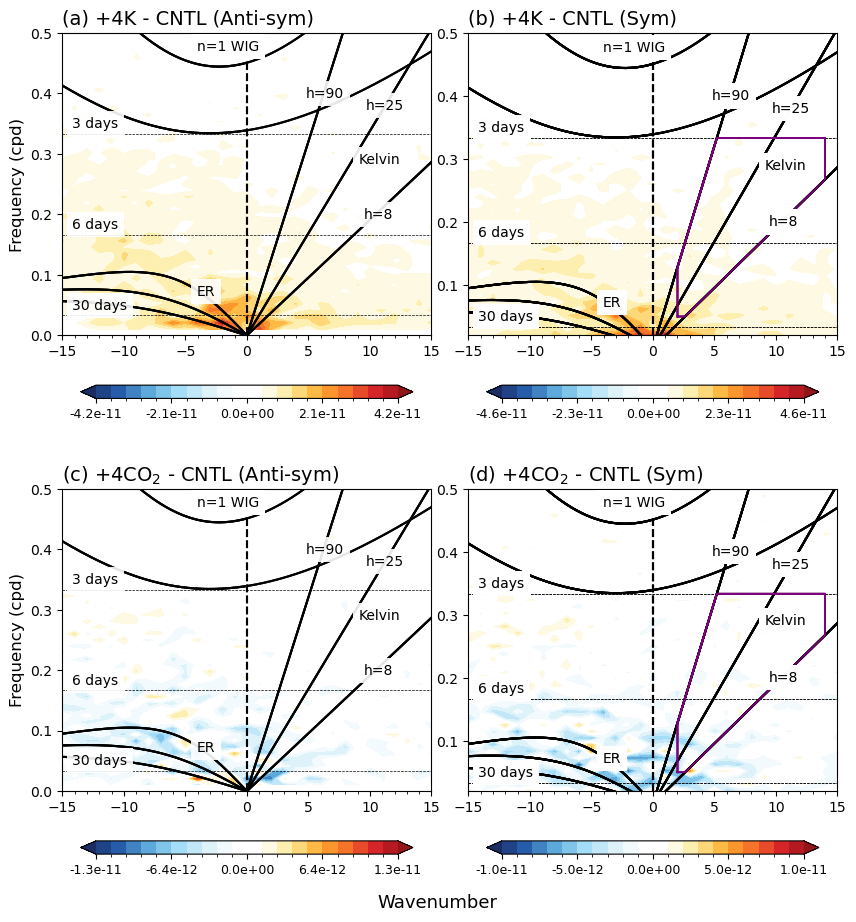

In [9]:
print("="*70)
print("📊 图4: 功率谱的差异（原始功率谱，mm/day单位，对称+反对称）")
print("="*70)

# 使用转换后的数据（mm/day单位）
try:
    # 检查是否已经计算了mm/day单位的频谱
    test_var = analysis_cntl_mmday
    print("✅ 使用 mm/day 单位的频谱数据")
    power_diff_4k_sym = analysis_4k_mmday.power_symmetric - analysis_cntl_mmday.power_symmetric
    power_diff_4co2_sym = analysis_4co2_mmday.power_symmetric - analysis_cntl_mmday.power_symmetric
    power_diff_4k_asym = analysis_4k_mmday.power_antisymmetric - analysis_cntl_mmday.power_antisymmetric
    power_diff_4co2_asym = analysis_4co2_mmday.power_antisymmetric - analysis_cntl_mmday.power_antisymmetric
except NameError:
    print("⚠️  警告：未找到 mm/day 单位的数据，使用原始数据")
    print("   建议先运行上面的单位转换代码单元！")
    power_diff_4k_sym = analysis_4k.power_symmetric - analysis_cntl.power_symmetric
    power_diff_4co2_sym = analysis_4co2.power_symmetric - analysis_cntl.power_symmetric
    power_diff_4k_asym = analysis_4k.power_antisymmetric - analysis_cntl.power_antisymmetric
    power_diff_4co2_asym = analysis_4co2.power_antisymmetric - analysis_cntl.power_antisymmetric

# 打印差异范围（使用科学计数法）
print(f"\n实际差异数据范围:")
print(f"4K - CNTL:")
print(f"  对称:   {np.nanmin(power_diff_4k_sym.values):.3e} - {np.nanmax(power_diff_4k_sym.values):.3e}")
print(f"  反对称: {np.nanmin(power_diff_4k_asym.values):.3e} - {np.nanmax(power_diff_4k_asym.values):.3e}")
print(f"4CO2 - CNTL:")
print(f"  对称:   {np.nanmin(power_diff_4co2_sym.values):.3e} - {np.nanmax(power_diff_4co2_sym.values):.3e}")
print(f"  反对称: {np.nanmin(power_diff_4co2_asym.values):.3e} - {np.nanmax(power_diff_4co2_asym.values):.3e}")

# ========== 自动计算色标范围（基于实际数据）==========
def get_symmetric_range(data):
    """获取对称的色标范围"""
    abs_max = max(abs(np.nanmin(data.values)), abs(np.nanmax(data.values)))
    # 增加10%的边距
    abs_max = abs_max * 1.1
    return -abs_max, abs_max

# 计算每个差异场的范围
vmin_4k_sym, vmax_4k_sym = get_symmetric_range(power_diff_4k_sym)
vmin_4k_asym, vmax_4k_asym = get_symmetric_range(power_diff_4k_asym)
vmin_4co2_sym, vmax_4co2_sym = get_symmetric_range(power_diff_4co2_sym)
vmin_4co2_asym, vmax_4co2_asym = get_symmetric_range(power_diff_4co2_asym)

print(f"\n自动计算的色标范围:")
print(f"4K 对称:   {vmin_4k_sym:.3e} - {vmax_4k_sym:.3e}")
print(f"4K 反对称: {vmin_4k_asym:.3e} - {vmax_4k_asym:.3e}")
print(f"4CO2 对称:   {vmin_4co2_sym:.3e} - {vmax_4co2_sym:.3e}")
print(f"4CO2 反对称: {vmin_4co2_asym:.3e} - {vmax_4co2_asym:.3e}")

# 创建2x2子图
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# 使用发散色图
cmap_diff = cmaps.BlueWhiteOrangeRed

# ============ 第1行：4K - CNTL ============
# 左：反对称
levels_4k_asym = np.linspace(vmin_4k_asym, vmax_4k_asym, 21)
im1 = power_diff_4k_asym.plot.contourf(
    ax=axes[0, 0], 
    cmap=cmap_diff,
    add_colorbar=False,
    extend='both', 
    levels=levels_4k_asym
)
axes[0, 0].set_title("(a) +4K - CNTL (Anti-sym)", fontsize=14, loc='left')

# 右：对称
levels_4k_sym = np.linspace(vmin_4k_sym, vmax_4k_sym, 21)
im2 = power_diff_4k_sym.plot.contourf(
    ax=axes[0, 1], 
    cmap=cmap_diff,
    add_colorbar=False,
    extend='both', 
    levels=levels_4k_sym
)
axes[0, 1].set_title("(b) +4K - CNTL (Sym)", fontsize=14,  loc='left')

# ============ 第2行：4CO2 - CNTL ============
# 左：反对称
levels_4co2_asym = np.linspace(vmin_4co2_asym, vmax_4co2_asym, 21)
im3 = power_diff_4co2_asym.plot.contourf(
    ax=axes[1, 0], 
    cmap=cmap_diff,
    add_colorbar=False,
    extend='both', 
    levels=levels_4co2_asym
)
axes[1, 0].set_title("(c) +4CO$_{2}$ - CNTL (Anti-sym)", fontsize=14,  loc='left')

# 右：对称
levels_4co2_sym = np.linspace(vmin_4co2_sym, vmax_4co2_sym, 21)
im4 = power_diff_4co2_sym.plot.contourf(
    ax=axes[1, 1], 
    cmap=cmap_diff,
    add_colorbar=False,
    extend='both', 
    levels=levels_4co2_sym
)
axes[1, 1].set_title("(d) +4CO$_{2}$ - CNTL (Sym)", fontsize=14,  loc='left')

# 格式化所有子图
diff_data = [power_diff_4k_asym, power_diff_4k_sym, power_diff_4co2_asym, power_diff_4co2_sym]
for i, (ax, data) in enumerate(zip(axes.flat, diff_data)):
    set_axis_for_wave(ax, text_size=16, kelvin_box=False)
    ax.axvline(0, linestyle='--', color='black', linewidth=1.5, alpha=0.7)
    
    ax.set_xlim([-15, 15])
    ax.set_ylim([0, 0.5])
    
    row_idx = i // 2
    if row_idx == 1:
        ax.set_xlabel("", fontsize=12,)
    else:
        ax.set_xlabel("")
    if i % 2 == 0:
        ax.set_ylabel("Frequency (cpd)", fontsize=12)
    else:   
        ax.set_ylabel("", fontsize=12)
        set_axis_for_wave(ax, text_size=16, kelvin_box=True)

# 为每个子图添加独立的colorbar（使用科学计数法）
cbar_axes = [axes[0, 0], axes[0, 1], axes[1, 0], axes[1, 1]]
cbar_ims = [im1, im2, im3, im4]
cbar_ranges = [
    (vmin_4k_asym, vmax_4k_asym),
    (vmin_4k_sym, vmax_4k_sym),
    (vmin_4co2_asym, vmax_4co2_asym),
    (vmin_4co2_sym, vmax_4co2_sym)
]

for ax, im, (vmin_val, vmax_val) in zip(cbar_axes, cbar_ims, cbar_ranges):
    cbar = fig.colorbar(im, ax=ax, orientation='horizontal', shrink=0.9, aspect=25, pad=0.12)
    n_ticks = 5
    tick_values = np.linspace(vmin_val, vmax_val, n_ticks)
    cbar.set_ticks(tick_values)
    # 使用科学计数法格式化标签
    cbar.ax.set_xticklabels([f'{val:.1e}' for val in tick_values], fontsize=9)
    
fig.text(0.5, 0.08, "Wavenumber", ha='center', va='center', fontsize=13)
# === 添加全局标题和布局调整 ===
fig.subplots_adjust(hspace=0.1, wspace=0.1, bottom=0.08, top=0.95)

plt.show()
fig.savefig(f"{fig_save_path}/fig04_power_spectrum_difference_4k_4co2_vs_cntl_mmday.png", dpi=300, bbox_inches='tight')
plt.close(fig)  # 释放内存，避免崩溃

In [10]:


def calculate_kelvin_wave_average_phase_speed(
    obs_data: xr.DataArray,
    frequency: np.ndarray,
    wavenumber: np.ndarray,
    fmin: float = 1/20,
    fmax: float = 1/3,
    kmin: int = 2,
    kmax: int = 14,
    hmin: float = 8,
    hmax: float = 90,
    plot_mask: bool = False
) -> float:
    """
    计算Kelvin波区域的平均相速度
    
    Parameters
    ----------
    obs_data : xr.DataArray
        观测数据频谱
    frequency : np.ndarray
        频率数组 (cycles/day)
    wavenumber : np.ndarray  
        波数数组
    fmin, fmax : float
        频率范围 (cycles/day)
    kmin, kmax : int
        波数范围
    hmin, hmax : float
        等效深度范围 (m)
    plot_mask : bool
        是否绘制mask图
        
    Returns
    -------
    avg_phase_speed : float
        Kelvin波区域平均相速度 (m/s)
    """
    
    # 物理常数
    g = 9.8  # 重力加速度
    beta = 2.28e-11  # 科里奥利参数梯度
    a = 6.37e6  # 地球半径
    earth_circumference = 40075e3  # 地球周长
    
    # 创建频率-波数网格
    knum, freq = np.meshgrid(wavenumber, frequency)
    
    # 初始化mask
    mask = np.zeros(knum.shape, dtype=bool)
    
    # 应用频率和波数范围限制
    if kmin is not None:
        mask = mask | (knum < kmin)
    if kmax is not None:
        mask = mask | (kmax < knum)
    if fmin is not None:
        mask = mask | (freq < fmin)
    if fmax is not None:
        mask = mask | (fmax < freq)
    
    # 应用等效深度范围限制（Kelvin波色散关系）
    if hmin is not None:
        c = np.sqrt(g * hmin)
        omega = 2. * np.pi * freq / 24. / 3600. / np.sqrt(beta * c)
        k = knum / a * np.sqrt(c / beta)
        mask = mask | (omega - k < 0)
    if hmax is not None:
        c = np.sqrt(g * hmax)
        omega = 2. * np.pi * freq / 24. / 3600. / np.sqrt(beta * c)
        k = knum / a * np.sqrt(c / beta)
        mask = mask | (omega - k > 0)
    
   
    
    # 应用mask到观测数据
    filtered_obs = obs_data * (~mask)
    
    # 找到有效的（非mask）格点
    valid_points = ~mask
     # 绘制mask（可选）
    if plot_mask:
        fig_mask = plt.figure(figsize=(10, 6))
        plt.contourf(knum, freq, filtered_obs, levels=np.linspace(0,0.3,21), cmap='viridis',
                     alpha=0.7)
        plt.colorbar(label='Filtered Power')
        plt.xlabel('Wavenumber')
        plt.ylabel('Frequency (cycles/day)')
        plt.title('Kelvin Wave Filter Mask')
        plt.grid(True, alpha=0.3)
        plt.xlim(-20,20)
        plt.show()
        plt.close(fig_mask)  # 释放内存
    # 计算加权平均相速度
    total_weighted_speed = 0
    total_weight = 0
    
    for i in range(knum.shape[0]):  # 频率维度
        for j in range(knum.shape[1]):  # 波数维度
            if valid_points[i, j] and filtered_obs[i, j] > 0:  # 有效且有功率
                f_val = freq[i, j]
                k_val = knum[i, j]
                
                # 计算相速度
                phase_speed = (2 * np.pi * f_val / 86400) / (k_val /a)
                
                # 用功率值作为权重
                weight = filtered_obs[i, j]
                total_weighted_speed += phase_speed * weight
                total_weight += weight
    
    # 计算加权平均相速度
    if total_weight > 0:
        avg_phase_speed = total_weighted_speed / total_weight
    else:
        avg_phase_speed = np.nan
        print("警告: 没有找到有效的Kelvin波区域数据点")
    
    return avg_phase_speed

开始综合分析：背景功率谱 vs 标准化频谱

正在分析 CNTL 实验...


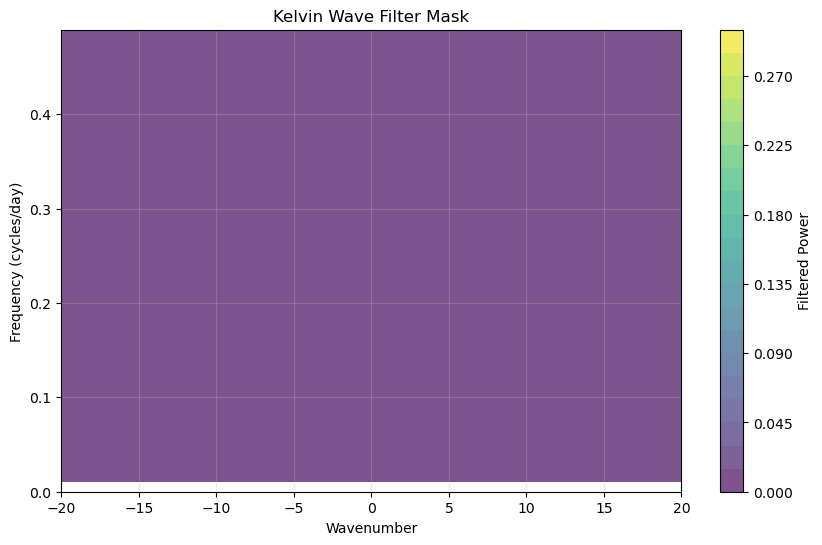


正在分析 4K 实验...


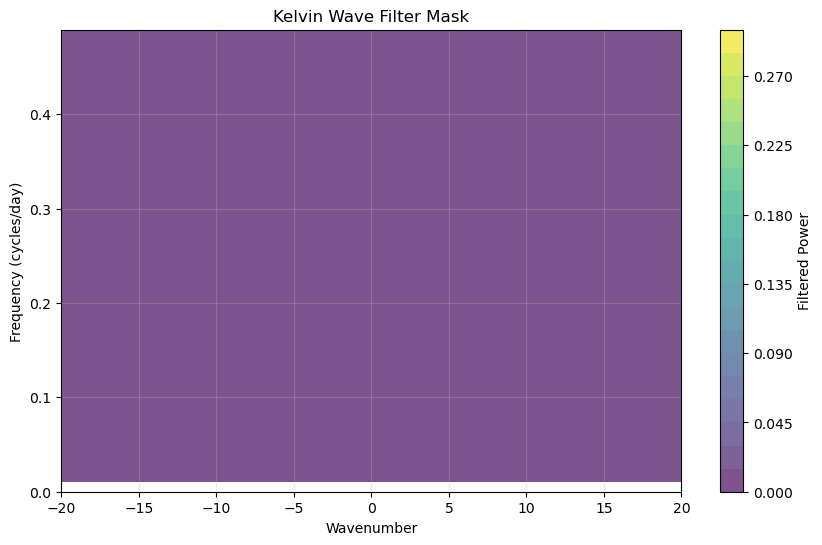


正在分析 4CO2 实验...


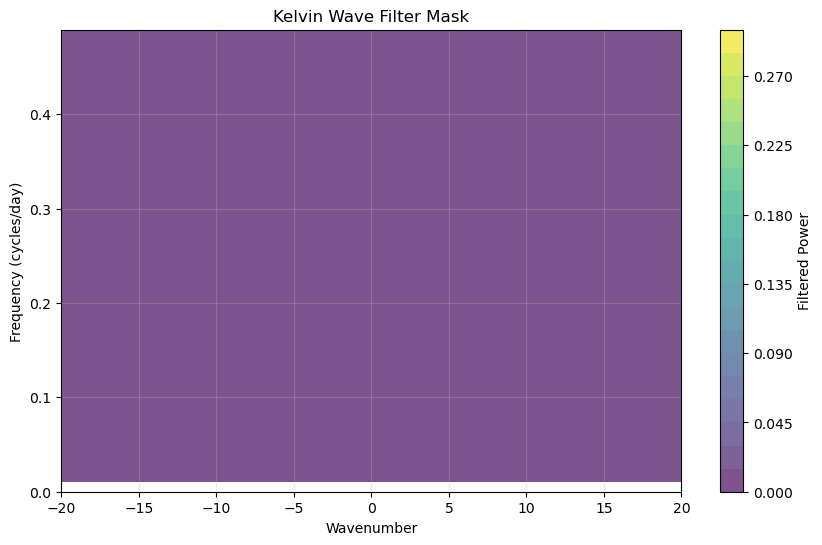


✅ 综合分析完成


In [11]:
# 对三个实验进行综合分析
print("="*80)
print("开始综合分析：背景功率谱 vs 标准化频谱")
print("="*80)

experiments = {
    'CNTL': analysis_cntl_mmday,
    '4K': analysis_4k_mmday,
    '4CO2': analysis_4co2_mmday
}

# 获取频率和波数数组
freq_array = experiments['CNTL'].frequency
wnum_array = experiments['CNTL'].wavenumber

average_phase_speed_results = {}
for exp_name, analysis_obj in experiments.items():
    print(f"\n正在分析 {exp_name} 实验...")
    average_phase_speed_results[exp_name] = calculate_kelvin_wave_average_phase_speed(
        analysis_obj.power_symmetric,
        freq_array,
        wnum_array,
        fmin=1/20,
        fmax=1/3,
        kmin=2,
        kmax=14,
        hmin=8,
        hmax=90,
        plot_mask=True
    )
    

print("\n" + "="*80)
print("✅ 综合分析完成")
print("="*80)